In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
24dimethylpentane,100.2,3.1426,3.925,238.91,0,0
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,24dimethylpentane,-0.01
"""

model = PCSAFT(["co2", "24dimethylpentane"], userlocations = [like_parameter, unlike_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 203.36052891795399; 203.36052891795399 238.91]
[2.785e-10 3.3550000000000003e-10; 3.3550000000000003e-10 3.925e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 323.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 323.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 10.0,
        :upper   => 200.0,
        :guess   => 130.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 200.0, :param => :epsilon, :indices => (1, 2), :guess => 130.0, :lower => 10.0)

In [5]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_24dimethylpentane.csv")
fix_line_endings("vley_24dimethylpentane.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_24dimethylpentane.csv"
        "vley_24dimethylpentane.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_24dimethylpentane.csv
Fixed: vley_24dimethylpentane.csv
Initial objective value: 1.0e100


In [6]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([188.82002294234152], PCSAFT{BasicIdeal, Float64}("co2", "24dimethylpentane"))

In [7]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 188.82002294234152; 188.82002294234152 238.91]
[2.785e-10 3.3550000000000003e-10; 3.3550000000000003e-10 3.925e-10]
kij = 0.06221613315774588


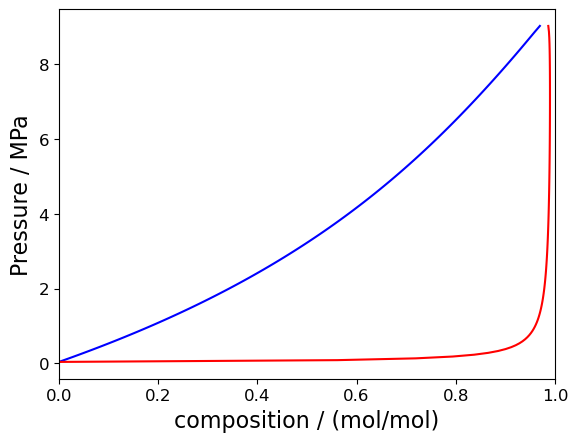

([-2.0, 0.0, 2.0, 4.0, 6.0, 8.0, 10.0], PyCall.PyObject[PyObject Text(0, -2.0, '−2'), PyObject Text(0, 0.0, '0'), PyObject Text(0, 2.0, '2'), PyObject Text(0, 4.0, '4'), PyObject Text(0, 6.0, '6'), PyObject Text(0, 8.0, '8'), PyObject Text(0, 10.0, '10')])

In [62]:
import PyPlot; const plt = PyPlot

N    = 100
T    = 323.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [63]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [64]:
aard_p   = calculate_AAD(model_opt, "vlep_24dimethylpentane.csv", vle_p)


=== AAD: vlep_24dimethylpentane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1825      1160000.000000  981568.874902  15.3820 
0.2980      2050000.000000  1692046.147837  17.4612 
0.4143      3070000.000000  2521955.219749  17.8516 
0.5214      4060000.000000  3413136.532672  15.9326 
0.6238      5030000.000000  4405440.645099  12.4167 
0.7224      6050000.000000  5515351.629532  8.8372  
0.7981      7050000.000000  6482087.511138  8.0555  
0.8791      8050000.000000  7627397.961870  5.2497  
0.9755      8670000.000000  9038674.725029  4.2523  
AARD = 11.7154%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


11.715415677812747

In [65]:
aard_p   = calculate_AAD(model_opt, "vley_24dimethylpentane.csv", vle_y)


=== AAD: vley_24dimethylpentane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1825      0.973600      0.959645      1.4333  
0.2980      0.981500      0.975277      0.6340  
0.4143      0.987400      0.982286      0.5179  
0.5214      0.989400      0.985908      0.3530  
0.6238      0.990800      0.988080      0.2745  
0.7224      0.990400      0.989392      0.1018  
0.7981      0.983200      0.989949      0.6864  
0.8791      0.974100      0.989993      1.6316  
0.9755      0.975500      0.975493      0.0007  
AARD = 0.6259%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.6259162023660232